# Environmental Sensor Data Analysis

## LSTM

The Long Short-Term Memory network (LSTM) is the advanced neural architecture employed here uses sequential memory cells connected through multiple layers, utilizing temporal backpropagation and addressing gradient decay issues inherent in deep learning systems.

This makes it effective for building extensive recurrent architectures.

Rather than traditional neurons, LSTM architectures utilize memory blocks interconnected across layers. These blocks function more intelligently than conventional neurons. Within each block, multiple gates regulate both its internal state and output behavior. These gates employ sigmoid activation functions to determine their triggering conditions, allowing them to selectively control state transitions and information flow through the block.

A memory block incorporates three gate types:

- The Forget Gate determines which information should be discarded from the block's state.

- The Input Gate selects which incoming values will modify the current memory state.

- The Output Gate controls what information gets passed forward based on both the input and stored memory.

- These gates function as components of a miniature state machine, with learnable weight parameters that get optimized throughout training.

It enables learning capabilities and memory retention within a single LSTM layer.

## Application to Environmental Humidity Prediction

Environmental moisture levels significantly impact human comfort perception and physiological responses. When moisture saturation is high, evaporation is inhibited, resulting in decreased cooling efficiency. Conversely, low saturation enables rapid moisture evaporation, enhancing cooling sensation. This inverse relationship between temperature and moisture perception creates complex thermal comfort dynamics requiring accurate prediction for environmental health monitoring systems.

The primary goal is to develop a predictive model that forecasts
atmospheric moisture levels at specific temporal intervals, utilizing multi-sensor environmental measurements as input features for the neural network architecture.

In [405]:
# Libraries
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
from datetime import datetime
import glob
import time

from keras.models import Sequential, load_model, save_model
from keras.callbacks import EarlyStopping
from keras.layers import LSTM
from keras.layers import Dense
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

rcParams['figure.figsize']=12,8
%matplotlib inline

## LSTM Model Implementation

The implemented LSTM architecture consists of a sequential model with 100 memory units in the LSTM layer, followed by a dense output layer with 1 unit for predicting the single target variable (relative humidity). The model is trained using the Mean Absolute Error (MAE) loss function and the Adam optimizer, with early stopping to prevent overfitting. The training process uses 50 epochs with a batch size of 100, evaluating performance on held-out test data.

Data preparation for LSTM involves creating time windows (lookback sequences) where the model learns to predict the next value based on the previous 8 hourly observations. This lookback window size balances the need for sufficient historical context while maintaining computational efficiency. The input data is normalized to the range [0, 1] using MinMaxScaler to stabilize training and improve convergence.

In [406]:
# Headers
col_names = ['date','time','carbon_monoxide_ref','sensor_co','nmhc_ref','benzene_ref','sensor_nmhc',
     'nitrogen_oxides_ref','sensor_nox','nitrogen_dioxide_ref','sensor_no2','sensor_o3', 'ambient_temp','relative_humidity','absolute_humidity']
col_numb = list(np.arange(len(col_names)))

# Load the data
sensor_df =pd.read_csv("sensor_data.csv",header=None,skiprows=1,names=col_names,na_filter=True,usecols=col_numb,na_values=-200,sep=";", decimal=",",index_col="date")

sensor_dataset = sensor_df.copy()

# Check data
sensor_dataset.head(), sensor_dataset.tail()

(                time  carbon_monoxide_ref  sensor_co  nmhc_ref  benzene_ref  \
 date                                                                          
 10/03/2004  18.00.00                  2.6     1360.0     150.0         11.9   
 10/03/2004  19.00.00                  2.0     1292.0     112.0          9.4   
 10/03/2004  20.00.00                  2.2     1402.0      88.0          9.0   
 10/03/2004  21.00.00                  2.2     1376.0      80.0          9.2   
 10/03/2004  22.00.00                  1.6     1272.0      51.0          6.5   
 
             sensor_nmhc  nitrogen_oxides_ref  sensor_nox  \
 date                                                       
 10/03/2004       1046.0                166.0      1056.0   
 10/03/2004        955.0                103.0      1174.0   
 10/03/2004        939.0                131.0      1140.0   
 10/03/2004        948.0                172.0      1092.0   
 10/03/2004        836.0                131.0      1205.0   
 
         

In [407]:
# Check data types
sensor_dataset.dtypes, sensor_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9471 entries, 10/03/2004 to nan
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  9357 non-null   object 
 1   carbon_monoxide_ref   7674 non-null   float64
 2   sensor_co             8991 non-null   float64
 3   nmhc_ref              914 non-null    float64
 4   benzene_ref           8991 non-null   float64
 5   sensor_nmhc           8991 non-null   float64
 6   nitrogen_oxides_ref   7718 non-null   float64
 7   sensor_nox            8991 non-null   float64
 8   nitrogen_dioxide_ref  7715 non-null   float64
 9   sensor_no2            8991 non-null   float64
 10  sensor_o3             8991 non-null   float64
 11  ambient_temp          8991 non-null   float64
 12  relative_humidity     8991 non-null   float64
 13  absolute_humidity     8991 non-null   float64
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


(time                     object
 carbon_monoxide_ref     float64
 sensor_co               float64
 nmhc_ref                float64
 benzene_ref             float64
 sensor_nmhc             float64
 nitrogen_oxides_ref     float64
 sensor_nox              float64
 nitrogen_dioxide_ref    float64
 sensor_no2              float64
 sensor_o3               float64
 ambient_temp            float64
 relative_humidity       float64
 absolute_humidity       float64
 dtype: object,
 None)

In [408]:
# Clean by replacing invalid sensor readings -200 with null values
# Remove last rows with incomplete observations
sensor_dataset = sensor_dataset.replace(-200, np.nan)
sensor_dataset.dropna(how='all',inplace=True)

In [409]:
sensor_dataset.shape

(9357, 14)

In [410]:
sensor_dataset.describe(), sensor_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9357 entries, 10/03/2004 to 04/04/2005
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  9357 non-null   object 
 1   carbon_monoxide_ref   7674 non-null   float64
 2   sensor_co             8991 non-null   float64
 3   nmhc_ref              914 non-null    float64
 4   benzene_ref           8991 non-null   float64
 5   sensor_nmhc           8991 non-null   float64
 6   nitrogen_oxides_ref   7718 non-null   float64
 7   sensor_nox            8991 non-null   float64
 8   nitrogen_dioxide_ref  7715 non-null   float64
 9   sensor_no2            8991 non-null   float64
 10  sensor_o3             8991 non-null   float64
 11  ambient_temp          8991 non-null   float64
 12  relative_humidity     8991 non-null   float64
 13  absolute_humidity     8991 non-null   float64
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


(       carbon_monoxide_ref    sensor_co     nmhc_ref  benzene_ref  \
 count          7674.000000  8991.000000   914.000000  8991.000000   
 mean              2.152750  1099.833166   218.811816    10.083105   
 std               1.453252   217.080037   204.459921     7.449820   
 min               0.100000   647.000000     7.000000     0.100000   
 25%               1.100000   937.000000    67.000000     4.400000   
 50%               1.800000  1063.000000   150.000000     8.200000   
 75%               2.900000  1231.000000   297.000000    14.000000   
 max              11.900000  2040.000000  1189.000000    63.700000   
 
        sensor_nmhc  nitrogen_oxides_ref   sensor_nox  nitrogen_dioxide_ref  \
 count  8991.000000          7718.000000  8991.000000           7715.000000   
 mean    939.153376           246.896735   835.493605            113.091251   
 std     266.831429           212.979168   256.817320             48.370108   
 min     383.000000             2.000000   322.00000

In [411]:
# Get hours to new column and drop time after
sensor_dataset['hour_test']=sensor_dataset['time'].apply(lambda x: int(x.split('.')[0]))
sensor_dataset.drop('time', axis=1, inplace=True)
sensor_dataset.head()

,carbon_monoxide_ref,sensor_co,nmhc_ref,benzene_ref,sensor_nmhc,nitrogen_oxides_ref,sensor_nox,nitrogen_dioxide_ref,sensor_no2,sensor_o3,ambient_temp,relative_humidity,absolute_humidity,hour_test
date,,,,,,,,,,,,,,
10/03/2004,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,18
10/03/2004,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,19
10/03/2004,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,20
10/03/2004,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,21
10/03/2004,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,22


In [412]:
# Check missing values
sensor_dataset.isnull().sum()

,0
carbon_monoxide_ref,1683
sensor_co,366
nmhc_ref,8443
benzene_ref,366
sensor_nmhc,366
nitrogen_oxides_ref,1639
sensor_nox,366
nitrogen_dioxide_ref,1642
sensor_no2,366
sensor_o3,366


In [413]:
# Drop column with NAs almost taking the whole column
sensor_dataset.drop('nmhc_ref',axis=1,inplace=True)

# Try mean impute
sensor_dataset['carbon_monoxide_ref'] = sensor_dataset['carbon_monoxide_ref'].fillna(sensor_dataset['carbon_monoxide_ref'].mean())
sensor_dataset['nitrogen_oxides_ref'] = sensor_dataset['nitrogen_oxides_ref'].fillna(sensor_dataset['nitrogen_oxides_ref'].mean())
sensor_dataset['nitrogen_dioxide_ref'] = sensor_dataset['nitrogen_dioxide_ref'].fillna(sensor_dataset['nitrogen_dioxide_ref'].mean())

for column in sensor_dataset.columns:
    if sensor_dataset[column].dtype in ['float64', 'float32', 'int64', 'int32']:
        sensor_dataset[column] = sensor_dataset[column].fillna(sensor_dataset[column].mean())

In [414]:
sensor_dataset.isnull().sum()

,0
carbon_monoxide_ref,0
sensor_co,0
benzene_ref,0
sensor_nmhc,0
nitrogen_oxides_ref,0
sensor_nox,0
nitrogen_dioxide_ref,0
sensor_no2,0
sensor_o3,0
ambient_temp,0


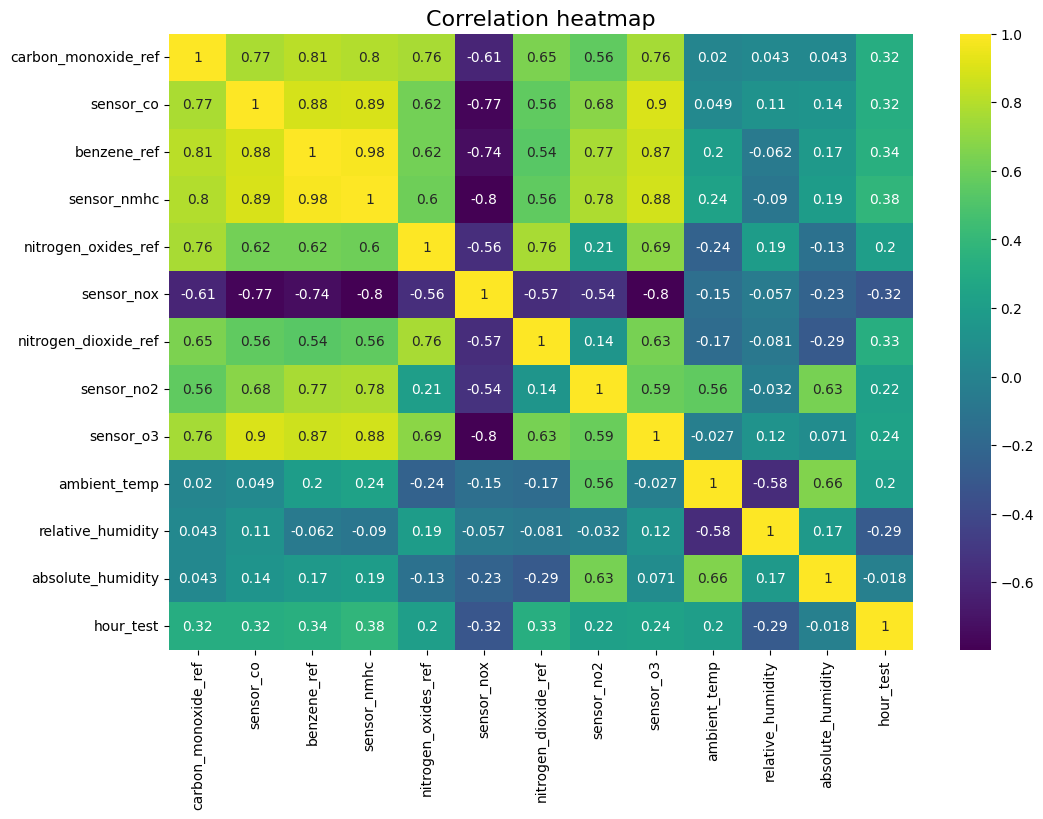

In [415]:
# Corelation between variables
sns.heatmap(sensor_dataset.corr(),annot=True,cmap='viridis')
plt.title('Correlation heatmap',fontsize=16)
plt.show()

In [416]:
# Split train/test
# Normalize data with MinMaxScaler
df = sensor_dataset.relative_humidity.values
df = df.astype('float32')
df = np.reshape(df, (-1, 1))
scaler = MinMaxScaler(feature_range=(0, 1))
df = scaler.fit_transform(df)
train_len = int(len(df) * 0.70)
test_len = len(df) - train_len
train, test = df[0:train_len,:], df[train_len:len(df),:]
print(len(train), len(test))

6549 2808


In [417]:
# Data prep function for time series forecasting,
# Do before feeding data into an LSTM model, future values are based on past observations.
def create_df(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    print(len(dataY))
    return np.array(dataX), np.array(dataY)

In [418]:
# Time frames with above function
look_back = 8
trainX, trainY = create_df(train, look_back)
testX, testY = create_df(test, look_back)

6541
2800


In [419]:
# Reshape data for the model
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))
print('Train size:',trainX.shape)
print('Test size:',testX.shape)

Train size: (6541, 1, 8)
Test size: (2800, 1, 8)


In [420]:
# Multi-layer sequential architecture with memory cells and dense output layer
lstm_model = Sequential([
    LSTM(100, input_shape=(trainX.shape[1], trainX.shape[2])),
    Dense(1)
])
lstm_model.compile(loss='mae', optimizer='adam')

# Train
history = lstm_model.fit(trainX, trainY, epochs=50, batch_size=100, validation_data=(testX, testY), verbose=1, shuffle=False)

# Check results
lstm_model.summary()

# Save model
lstm_model.save('ltsm_model.hdf5')

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3032 - val_loss: 0.0899
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0952 - val_loss: 0.0663
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0656 - val_loss: 0.0596
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0565 - val_loss: 0.0568
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0540 - val_loss: 0.0546
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0519 - val_loss: 0.0546
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0507 - val_loss: 0.0531
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0493 - val_loss: 0.0509
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0481 - val_loss: 0.0531
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0477 - val_loss: 0.0510
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0467 - val_loss: 0.0512
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0464 - val_loss: 0.0497


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 100)            │        43,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,105 (512.13 KB)

 Trainable params: 43,701 (170.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 87,404 (341.43 KB)

In [421]:
# Predict for 1 year on 5 previous years
yhat = lstm_model.predict(testX)

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


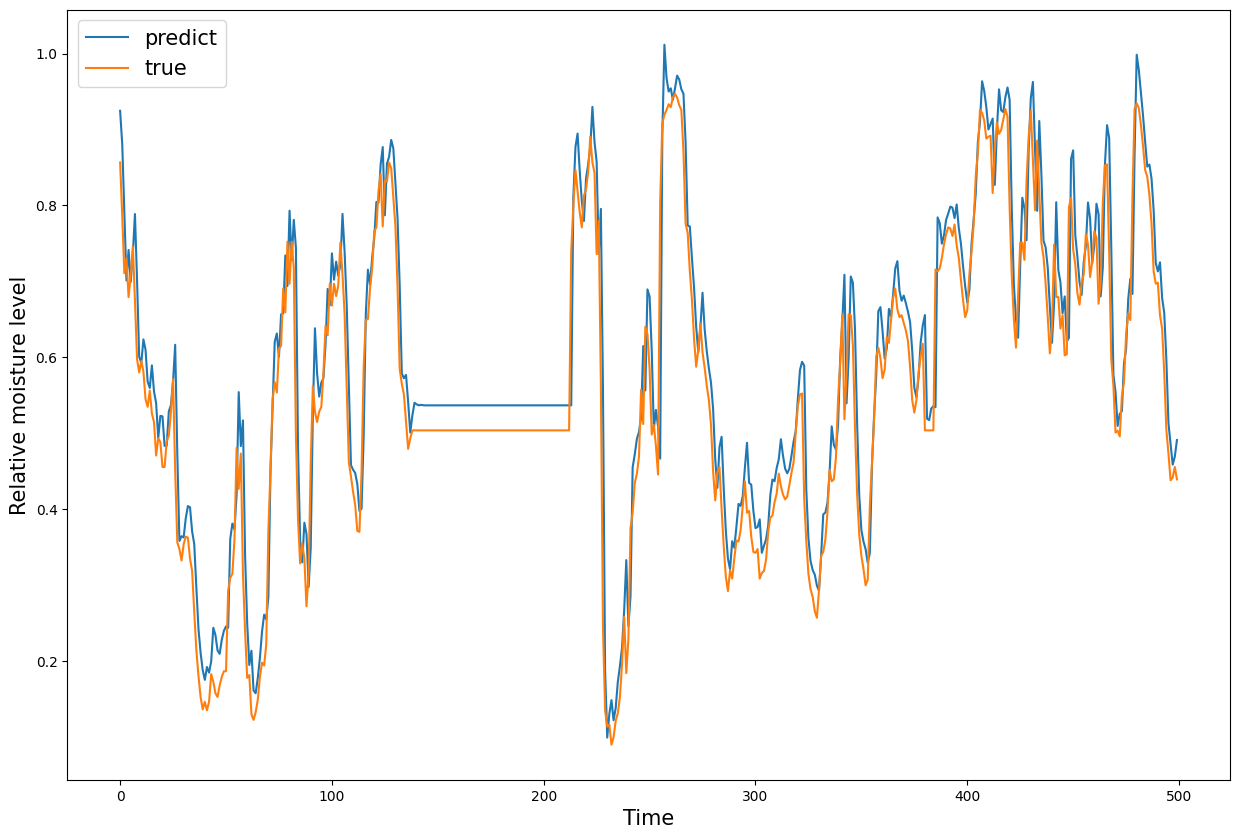

In [422]:
# Plot 500 first entries
pyplot.figure(figsize=(15,10))
pyplot.plot(yhat[:500], label='predict')
pyplot.plot(testY[:500], label='true')
pyplot.legend()

pyplot.ylabel('Relative moisture level', size=15)
pyplot.xlabel('Time', size=15)
pyplot.legend(fontsize=15)

pyplot.show()

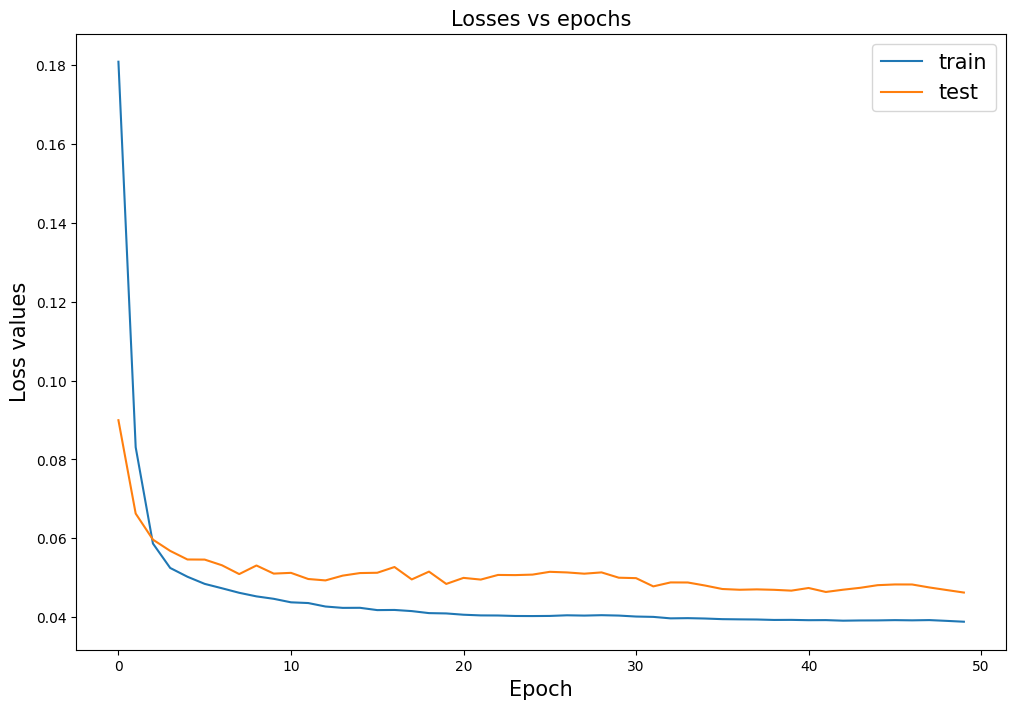

In [423]:
# Model loss
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')

pyplot.title('Losses vs epochs',size=15)
pyplot.ylabel('Loss values',size=15)
pyplot.xlabel('Epoch',size=15)
pyplot.legend(loc='upper right',fontsize=15)

pyplot.show()

## ARIMA

The ARIMA model represents a classical statistical approach to time series forecasting. An ARIMA model analyzes and forecasts time series data by decomposing it into three fundamental components that work in concert: autoregression (AR), integration (I), and moving average (MA).

AutoRegression (AR) models use past values of the time series to predict current values, assuming that historical observations contain predictive information about future values. The model learns linear relationships between past observations and the current value through estimated coefficients.

Integration (I) addresses non-stationarity in the time series by applying differencing transformations. These transformations subtract observations from previous time steps, effectively removing trends and seasonal patterns that would violate the stationarity assumptions underlying ARIMA models. The number of differencing operations determines the order of integration.

Moving Average (MA) models capture the dependency between observations and residual errors from a moving average process applied to lagged observations. This component allows the model to account for random shocks and short-term fluctuations that are not explained by the autoregressive component.

The ARIMA model is formally denoted as ARIMA(p, d, q), where p represents the number of autoregressive terms, d represents the degree of differencing, and q represents the order of the moving average. By appropriately selecting these parameters through statistical testing and model validation, the ARIMA framework can effectively remove trends and seasonal effects while providing interpretable and accurate predictions.

*Stationarity and Differencing*
Before fitting an ARIMA model, the time series must be verified for stationarity using the Augmented Dickey-Fuller (ADF) test. A stationary time series exhibits constant mean and variance over time, with no trends or seasonal patterns. The ADF test provides a test statistic and p-value; if the p-value is below the significance level (typically 0.05), the series is considered stationary.

In cases where raw data is non-stationary, differencing is applied. First-order differencing subtracts each observation from the previous observation, effectively removing trends. Higher-order differencing can be applied if needed to achieve stationarity. The first step in ARIMA analysis involves log-transforming the data to stabilize variance, then applying differencing to achieve stationarity. The model is fit on the differenced (stationary) data, and predictions are subsequently inverse-transformed back to the original scale.

*Model Fitting and Evaluation*
The ARIMA(2,1,2) model was selected for this analysis through iterative parameter tuning and AIC/BIC criteria. This model specification indicates:

p=2: Two autoregressive terms are included

d=1: First-order differencing is applied to achieve stationarity

q=2: Two moving average terms are included

The model achieves excellent performance metrics on historical data:

RMSE (Root Mean Squared Error): 4.37, indicating predictions deviate from actual values by approximately 4.4% on average

MAE (Mean Absolute Error): 2.94, representing the average absolute prediction error

MAPE (Mean Absolute Percentage Error): 6.61%, a very low percentage error indicating high prediction accuracy

Mean Values: Actual mean humidity of 49.23% vs. fitted mean of 49.41% (excellent agreement)

Standard Deviations: Actual std of 16.97% vs. fitted std of 17.40% (very close variance capture)

These metrics demonstrate that the ARIMA model successfully captures both the level and variability of humidity patterns in the environmental sensor data.

In [424]:
import numpy as np
from matplotlib.pylab import rcParams
import matplotlib.pylab as plt
import pandas as pd
from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.stattools import adfuller
%matplotlib inline

rcParams['figure.figsize'] = 10,6

In [425]:
arima_df = sensor_df.copy()

In [426]:
# Index column date to regular column
# Combine date and time into seprate series
from datetime import datetime
arima_df = arima_df.reset_index()
arima_df = arima_df.dropna(subset=['date', 'time'])
arima_df['datetime'] = arima_df['date'].astype(str) + ' ' + arima_df['time'].astype(str)

DateTime = []
for x in arima_df['datetime']:
    DateTime.append(datetime.strptime(x,'%d/%m/%Y %H.%M.%S'))

datetime = pd.Series(DateTime)
arima_df.index = datetime

# Replace wrong data with NA
arima_df = arima_df.replace(-200, np.nan)

In [427]:
arima_df.head()

,date,time,carbon_monoxide_ref,sensor_co,nmhc_ref,benzene_ref,sensor_nmhc,nitrogen_oxides_ref,sensor_nox,nitrogen_dioxide_ref,sensor_no2,sensor_o3,ambient_temp,relative_humidity,absolute_humidity,datetime
2004-03-10 18:00:00,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,10/03/2004 18.00.00
2004-03-10 19:00:00,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,10/03/2004 19.00.00
2004-03-10 20:00:00,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,10/03/2004 20.00.00
2004-03-10 21:00:00,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,10/03/2004 21.00.00
2004-03-10 22:00:00,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,10/03/2004 22.00.00


In [428]:
arima_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  9357 non-null   object 
 1   time                  9357 non-null   object 
 2   carbon_monoxide_ref   7674 non-null   float64
 3   sensor_co             8991 non-null   float64
 4   nmhc_ref              914 non-null    float64
 5   benzene_ref           8991 non-null   float64
 6   sensor_nmhc           8991 non-null   float64
 7   nitrogen_oxides_ref   7718 non-null   float64
 8   sensor_nox            8991 non-null   float64
 9   nitrogen_dioxide_ref  7715 non-null   float64
 10  sensor_no2            8991 non-null   float64
 11  sensor_o3             8991 non-null   float64
 12  ambient_temp          8991 non-null   float64
 13  relative_humidity     8991 non-null   float64
 14  absolute_humidity     8991 non-null 

In [429]:
# Drop column with NAs almost taking the whole column
arima_df.drop('nmhc_ref',axis=1,inplace=True)

# Try mean impute
Sensor_1 = arima_df['sensor_co'].fillna(arima_df['sensor_co'].mean())
Sensor_2 = arima_df['sensor_nmhc'].fillna(arima_df['sensor_nmhc'].mean())
Sensor_3 = arima_df['sensor_nox'].fillna(arima_df['sensor_nox'].mean())
Sensor_4 = arima_df['sensor_no2'].fillna(arima_df['sensor_no2'].mean())
Sensor_5 = arima_df['sensor_o3'].fillna(arima_df['sensor_o3'].mean())
Sensor_6 = arima_df['relative_humidity'].fillna(arima_df['relative_humidity'].mean())

In [430]:
sensor_plot_df = pd.DataFrame({
    'Sensor_1': Sensor_1,
    'Sensor_2': Sensor_2,  # Changed from Sensor_1
    'Sensor_3': Sensor_3,
    'Sensor_4': Sensor_4,
    'Sensor_5': Sensor_5,
    'Sensor_6': Sensor_6
})

Text(0.5, 1.0, 'Sensor_6')

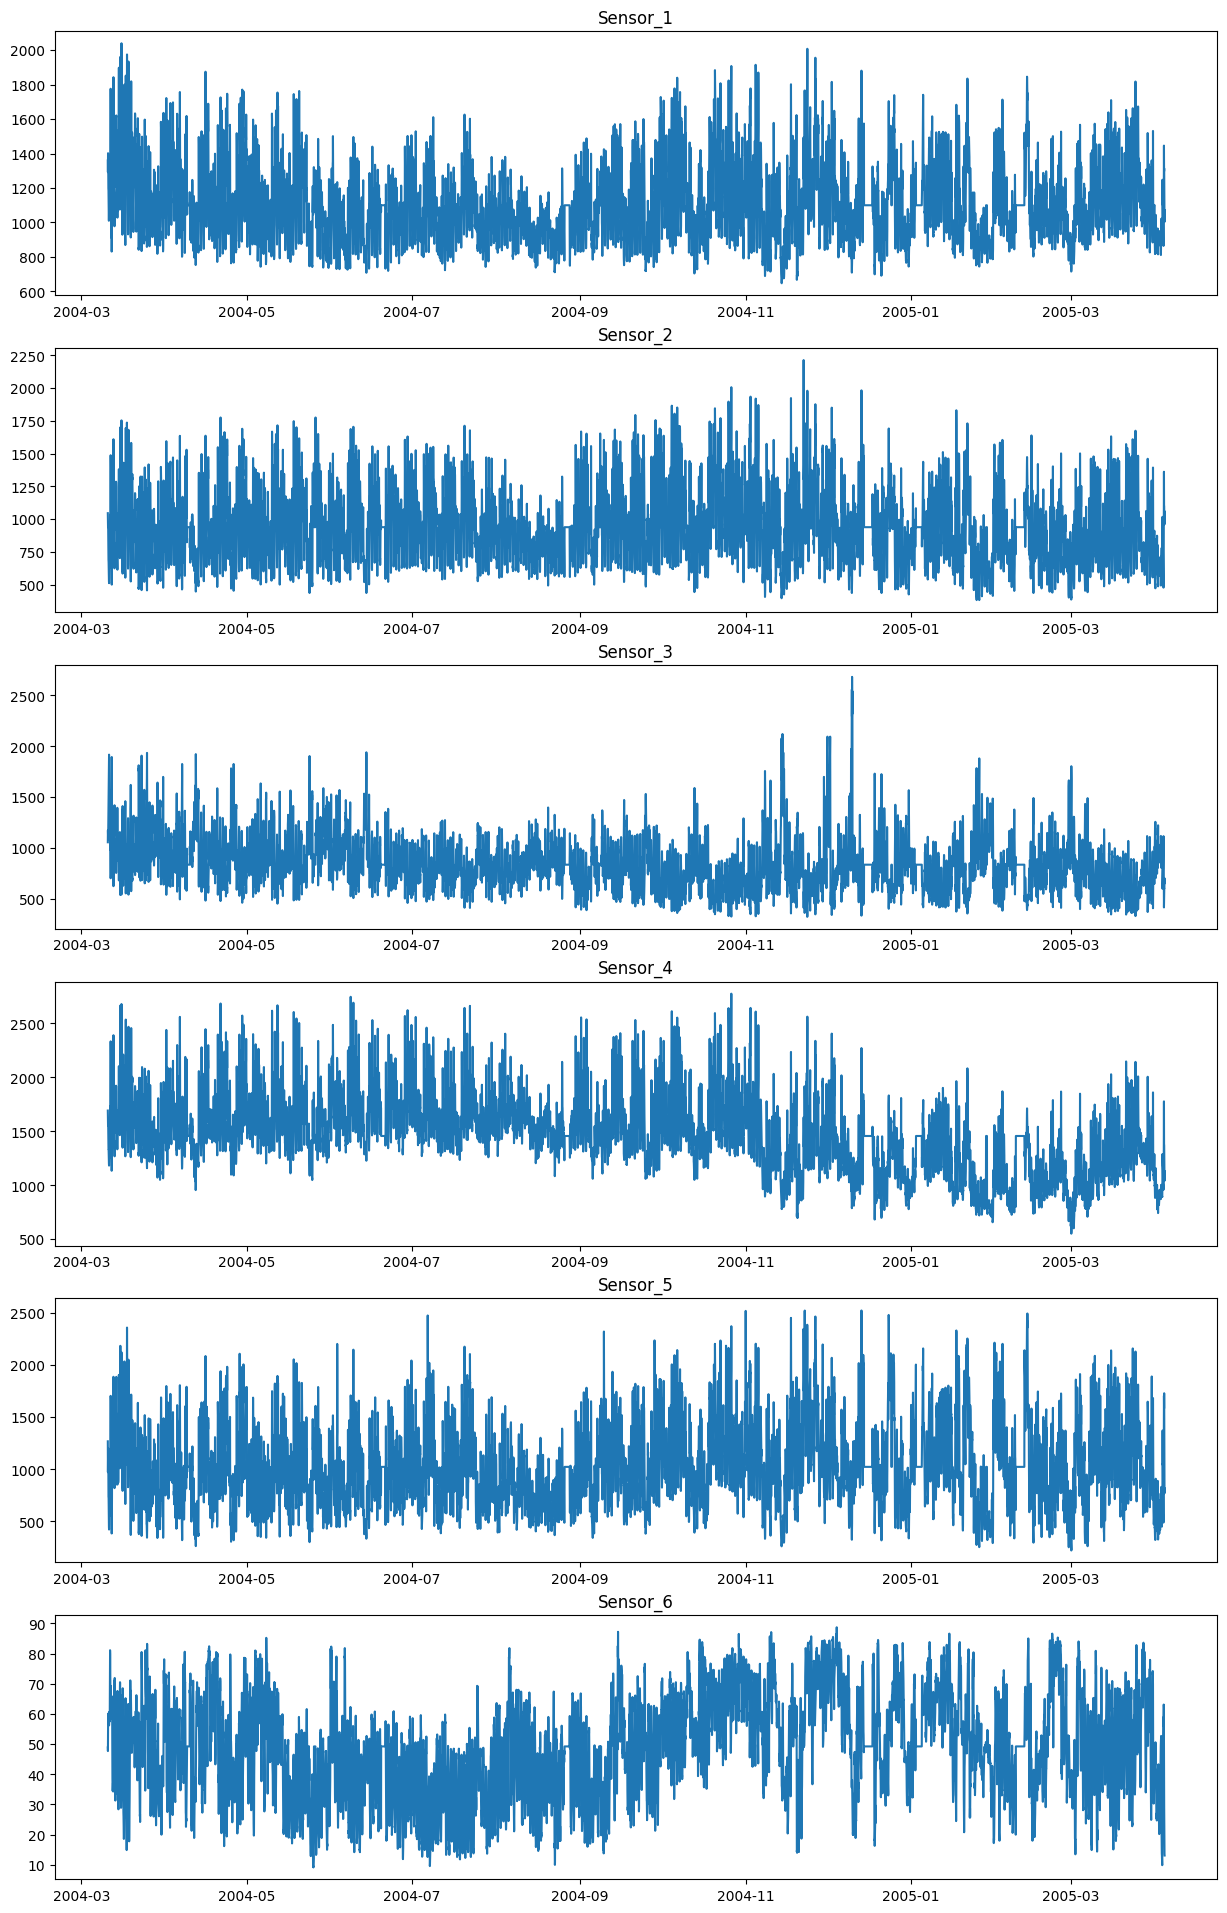

In [431]:
fig, axes = plt.subplots(6,1, figsize=(15,24))

axes[0].plot(Sensor_1)
axes[0].set_title ('Sensor_1')
axes[1].plot(Sensor_2)
axes[1].set_title ('Sensor_2')
axes[2].plot(Sensor_3)
axes[2].set_title ('Sensor_3')
axes[3].plot(Sensor_4)
axes[3].set_title ('Sensor_4')
axes[4].plot(Sensor_5)
axes[4].set_title ('Sensor_5')
axes[5].plot(Sensor_6)
axes[5].set_title ('Sensor_6')

Text(0.5, 1.0, 'Sensor_6')

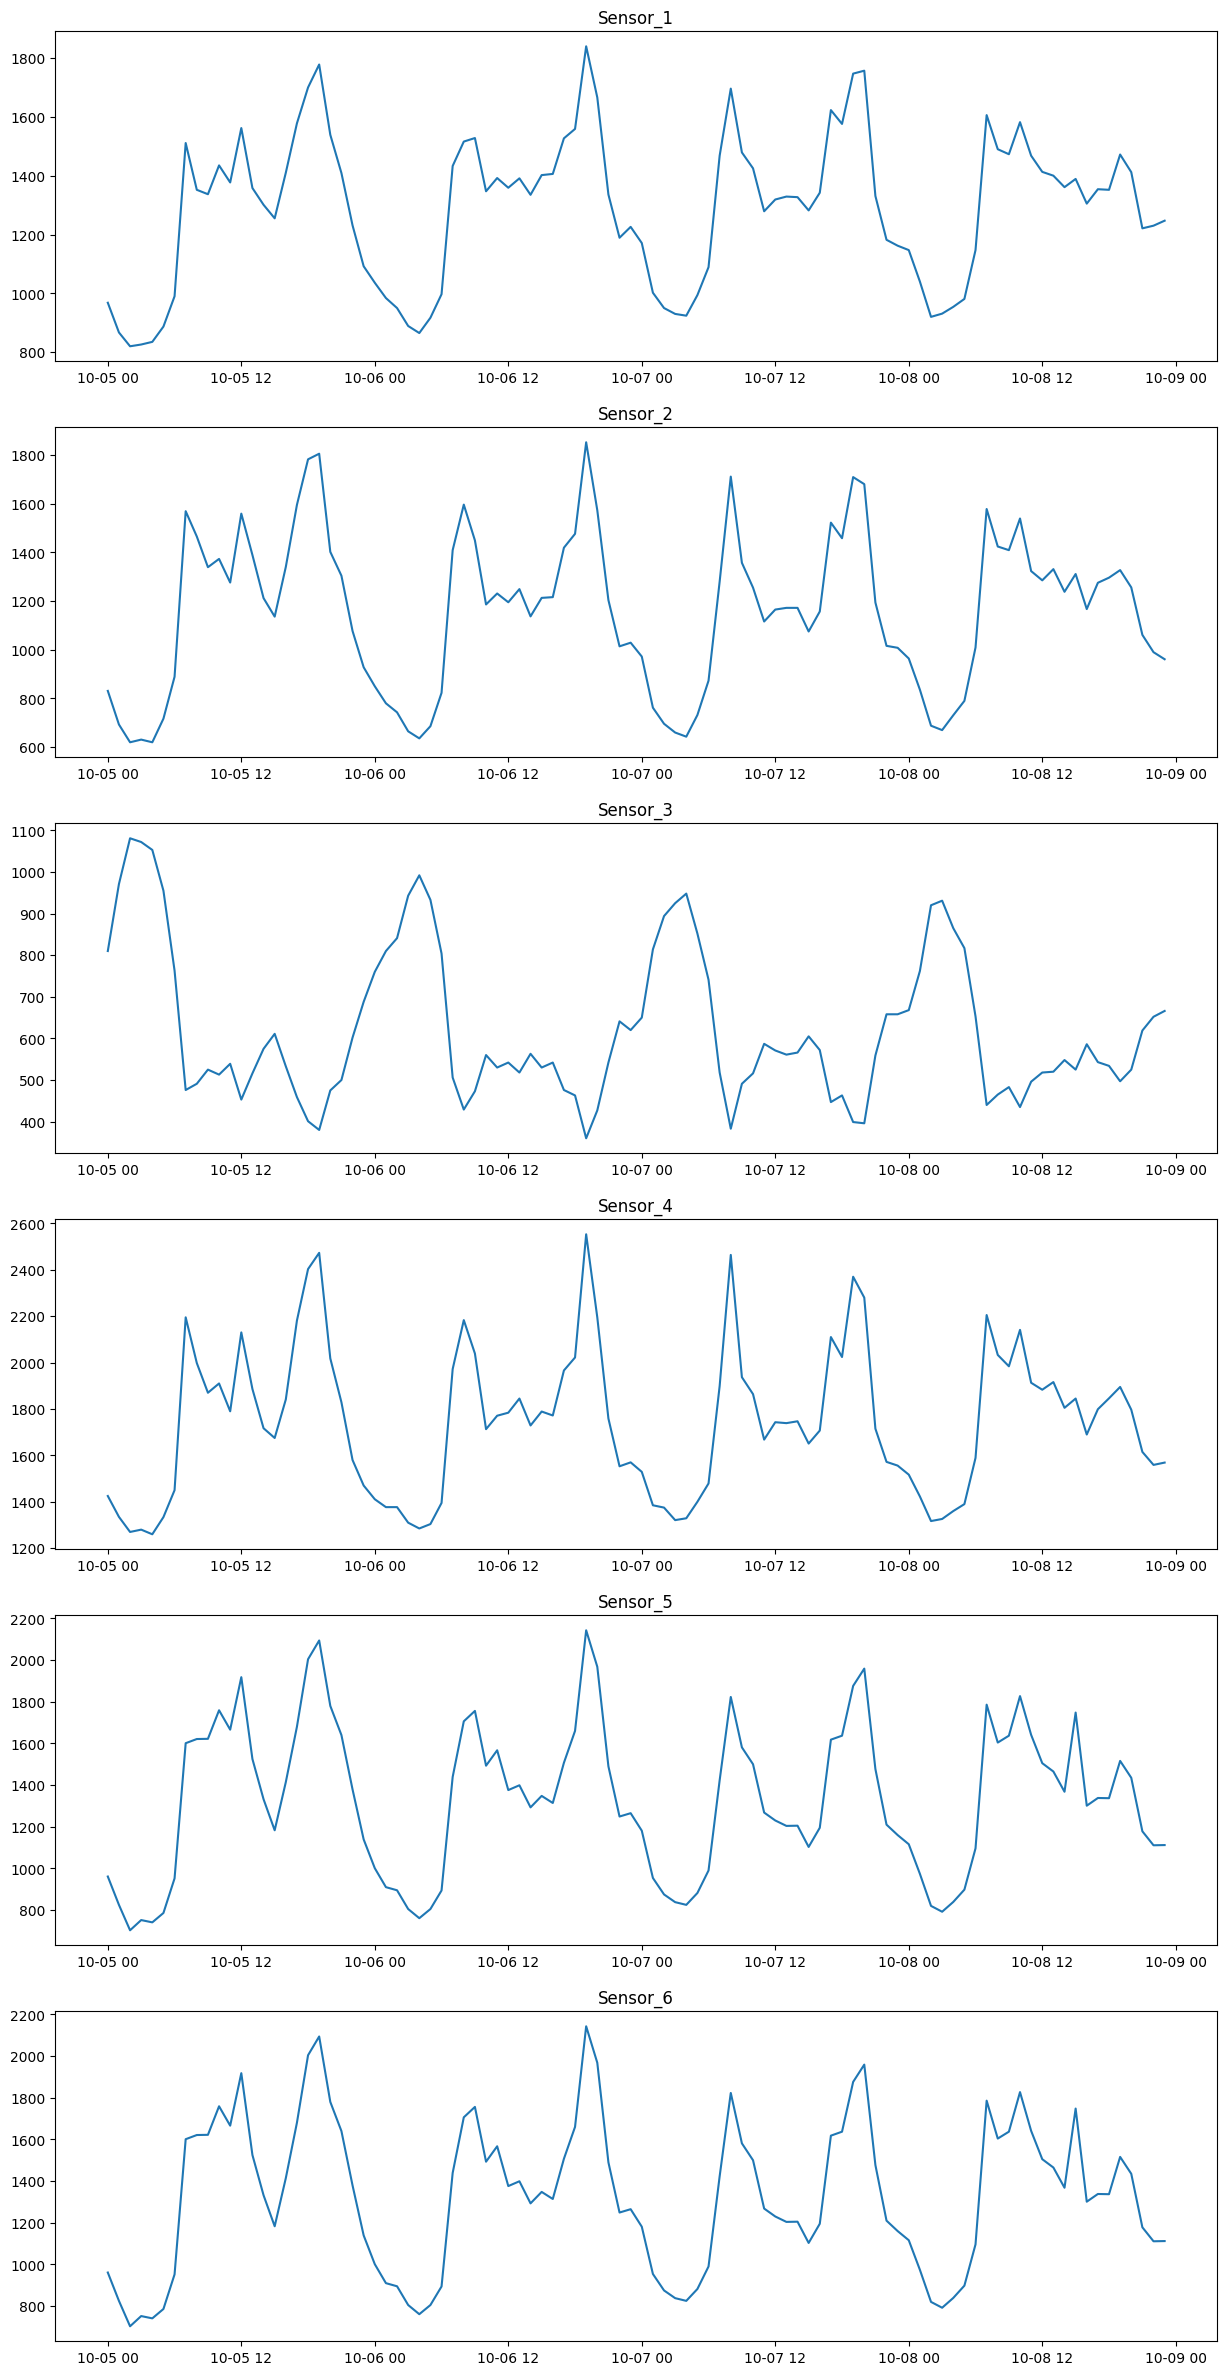

In [432]:
fig, axes = plt.subplots(6,1, figsize=(15,30))

axes[0].plot(Sensor_1['2004-10-05':'2004-10-08'])
axes[0].set_title ('Sensor_1')
axes[1].plot(Sensor_2['2004-10-05':'2004-10-08'])
axes[1].set_title ('Sensor_2')
axes[2].plot(Sensor_3['2004-10-05':'2004-10-08'])
axes[2].set_title ('Sensor_3')
axes[3].plot(Sensor_4['2004-10-05':'2004-10-08'])
axes[3].set_title ('Sensor_4')
axes[4].plot(Sensor_5['2004-10-05':'2004-10-08'])
axes[4].set_title ('Sensor_5')
axes[5].plot(Sensor_5['2004-10-05':'2004-10-08'])
axes[5].set_title ('Sensor_6')

In [433]:
target_df = pd.DataFrame({'Sensor_6': Sensor_6})
target_df.head(), target_df.isnull().sum(), target_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Sensor_6  9357 non-null   float64
dtypes: float64(1)
memory usage: 404.2 KB


(                     Sensor_6
 2004-03-10 18:00:00      48.9
 2004-03-10 19:00:00      47.7
 2004-03-10 20:00:00      54.0
 2004-03-10 21:00:00      60.0
 2004-03-10 22:00:00      59.6,
 Sensor_6    0
 dtype: int64,
 None)

In [434]:
# Calculate moving average and standard deviation
moving_average = target_df.rolling(window=12).mean()
moving_std = target_df.rolling(window=12).std()
print(moving_average, moving_std)

                      Sensor_6
2004-03-10 18:00:00        NaN
2004-03-10 19:00:00        NaN
2004-03-10 20:00:00        NaN
2004-03-10 21:00:00        NaN
2004-03-10 22:00:00        NaN
...                        ...
2005-04-04 10:00:00  52.141667
2005-04-04 11:00:00  49.741667
2005-04-04 12:00:00  46.983333
2005-04-04 13:00:00  43.841667
2005-04-04 14:00:00  40.241667

[9357 rows x 1 columns]                       Sensor_6
2004-03-10 18:00:00        NaN
2004-03-10 19:00:00        NaN
2004-03-10 20:00:00        NaN
2004-03-10 21:00:00        NaN
2004-03-10 22:00:00        NaN
...                        ...
2005-04-04 10:00:00  10.171838
2005-04-04 11:00:00  13.065601
2005-04-04 12:00:00  15.875472
2005-04-04 13:00:00  18.481561
2005-04-04 14:00:00  19.980830

[9357 rows x 1 columns]


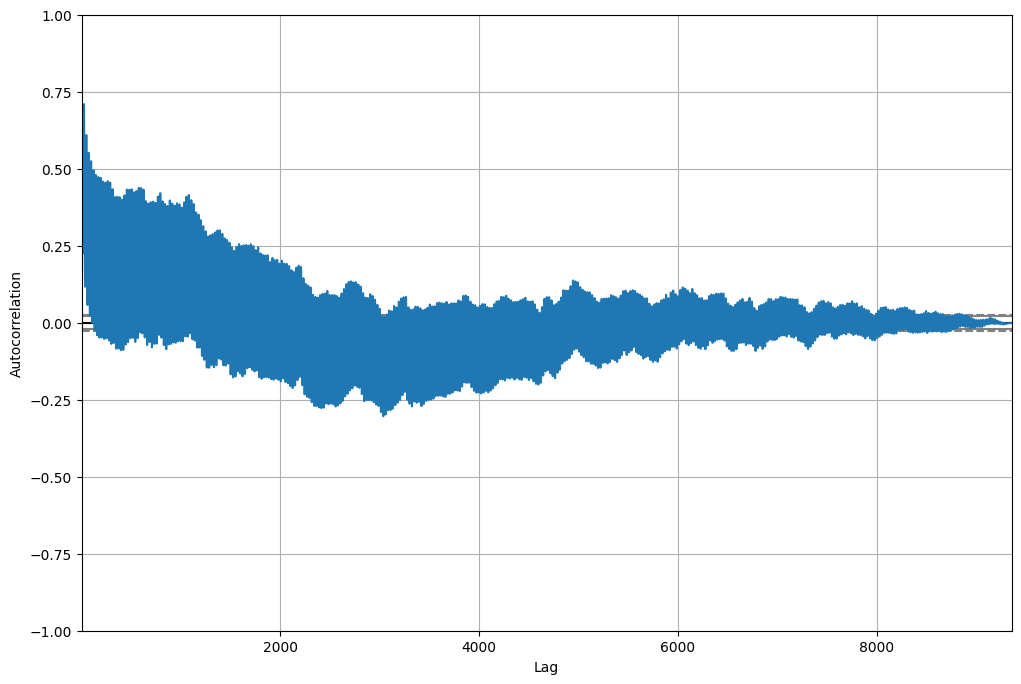

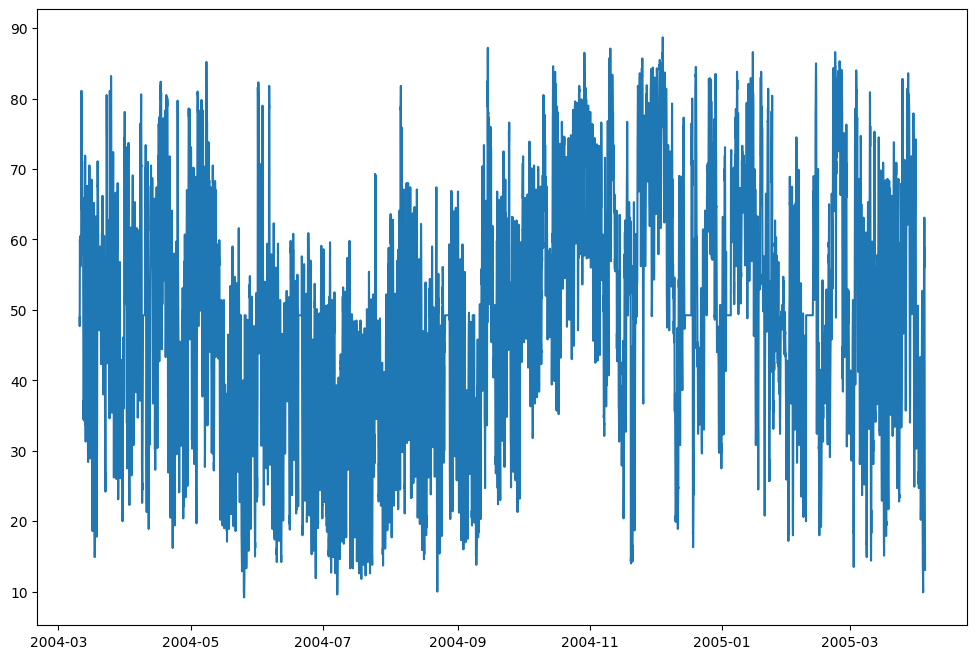

In [435]:
rcParams['figure.figsize'] = 12,8
autocorrelation_plot(target_df)
pyplot.show()

pyplot.plot(target_df)
pyplot.show()

Dickey fuller test
Test Statistic               -7.391164e+00
p-value                       7.993979e-11
#Lags Used                    3.800000e+01
Number of observation Used    9.318000e+03
Critical Value (1%)          -3.431052e+00
Critical Value (5%)          -2.861850e+00
Critical Value (10%)         -2.566935e+00
dtype: float64


,Sensor_6
2004-03-11 05:00:00,-0.009338
2004-03-11 06:00:00,0.009545
2004-03-11 07:00:00,0.016475
2004-03-11 08:00:00,-0.026225
2004-03-11 09:00:00,0.027196
2004-03-11 10:00:00,-0.008088
2004-03-11 11:00:00,-0.014836
2004-03-11 12:00:00,0.114636
2004-03-11 13:00:00,0.228779
2004-03-11 14:00:00,0.262950


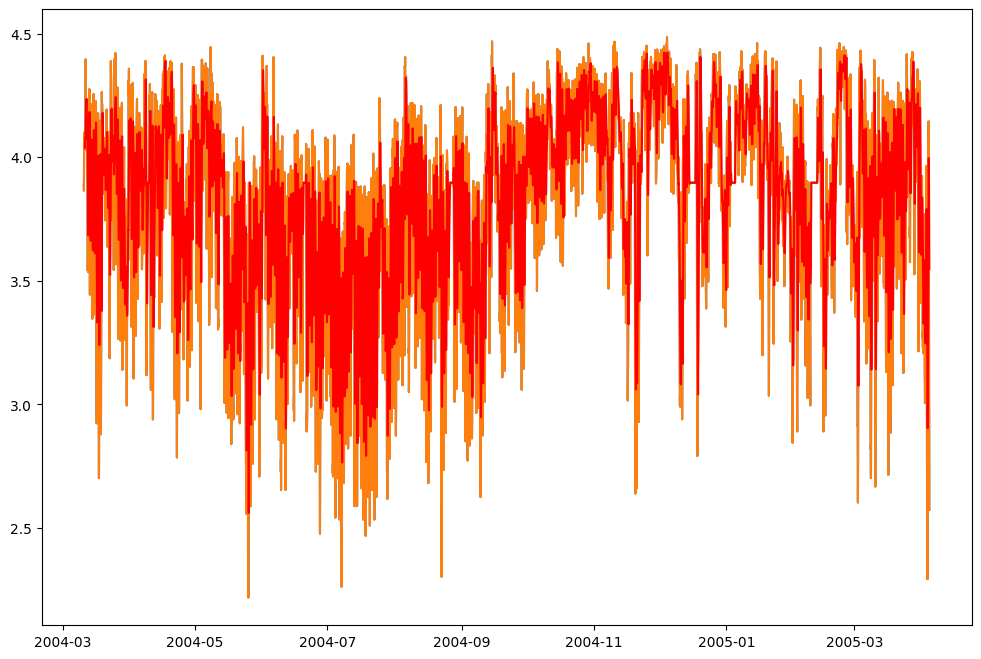

In [436]:
# Dickey-fuller test
print ('Dickey fuller test')
dftest= adfuller(target_df['Sensor_6'],autolag='AIC')
dfoutput = pd.Series(dftest[0:4],index=['Test Statistic','p-value','#Lags Used','Number of observation Used'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key]=value

print(dfoutput)

# Estimate trend
target_df_logScale = np.log(target_df)
plt.plot(target_df_logScale)

# Moving Average
moving_average = target_df_logScale.rolling(window=12).mean()
moving_std = target_df_logScale.rolling(window=12).std()
plt.plot(target_df_logScale)
plt.plot(moving_average,color='red')

detrended_series = target_df_logScale - moving_average
detrended_series.head(12)
detrended_series.dropna(inplace=True)
detrended_series.head(10)

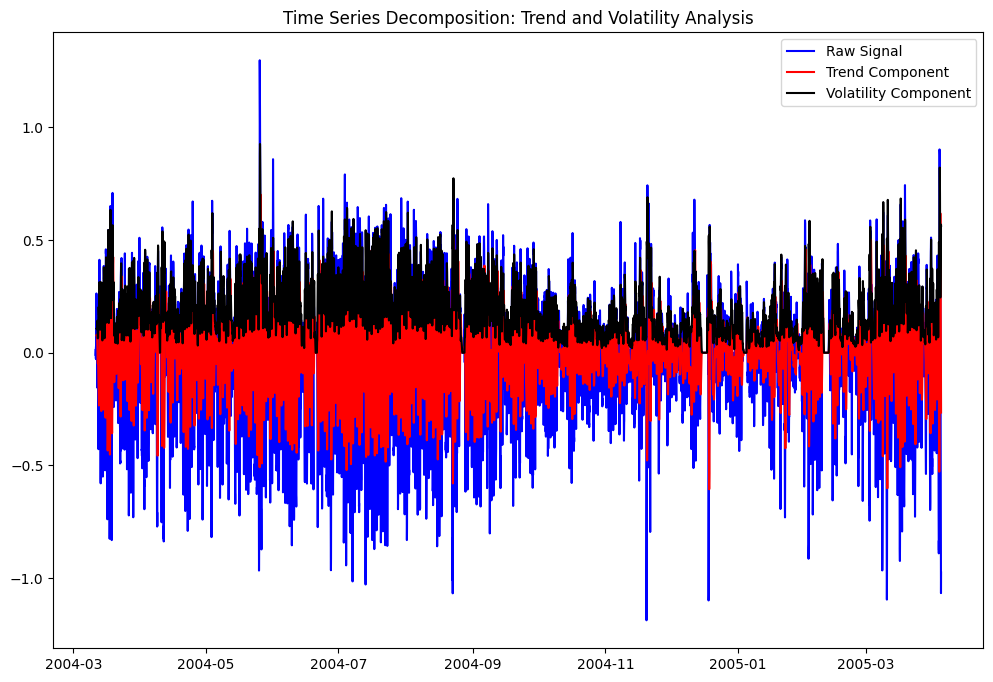

Augmented Dickey Fuller Test Results
Test Metric              -22.527486
P-value                    0.000000
Lags Applied              37.000000
Sample Size             9308.000000
Critical Level (1%)       -3.431053
Critical Level (5%)       -2.861851
Critical Level (10%)      -2.566935
dtype: float64


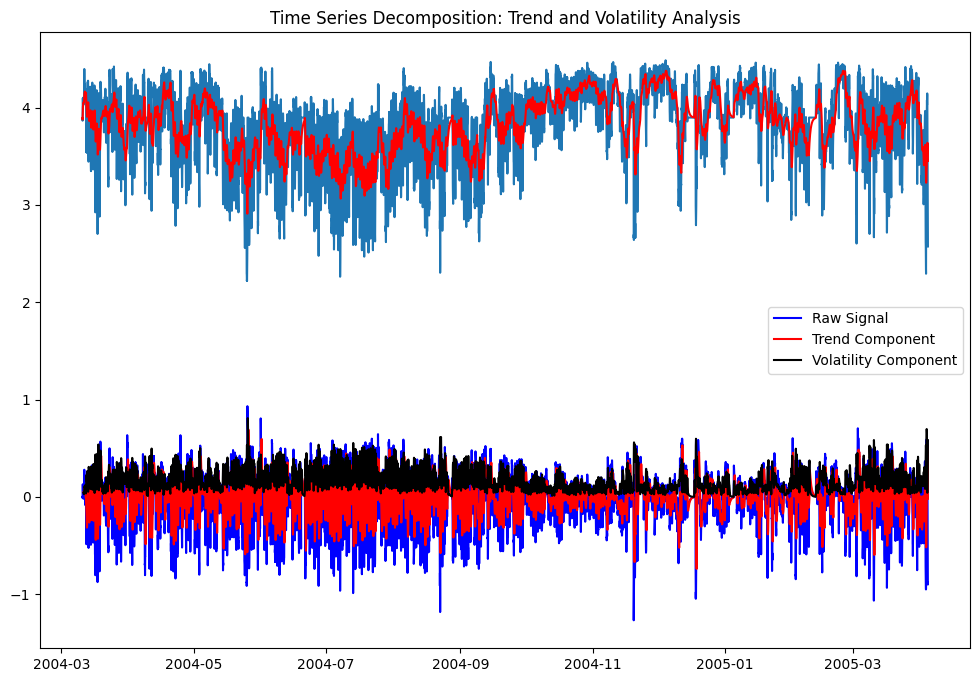

Augmented Dickey Fuller Test Results
Test Metric            -1.858574e+01
P-value                 2.075804e-30
Lags Applied            3.600000e+01
Sample Size             9.320000e+03
Critical Level (1%)    -3.431052e+00
Critical Level (5%)    -2.861850e+00
Critical Level (10%)   -2.566935e+00
dtype: float64


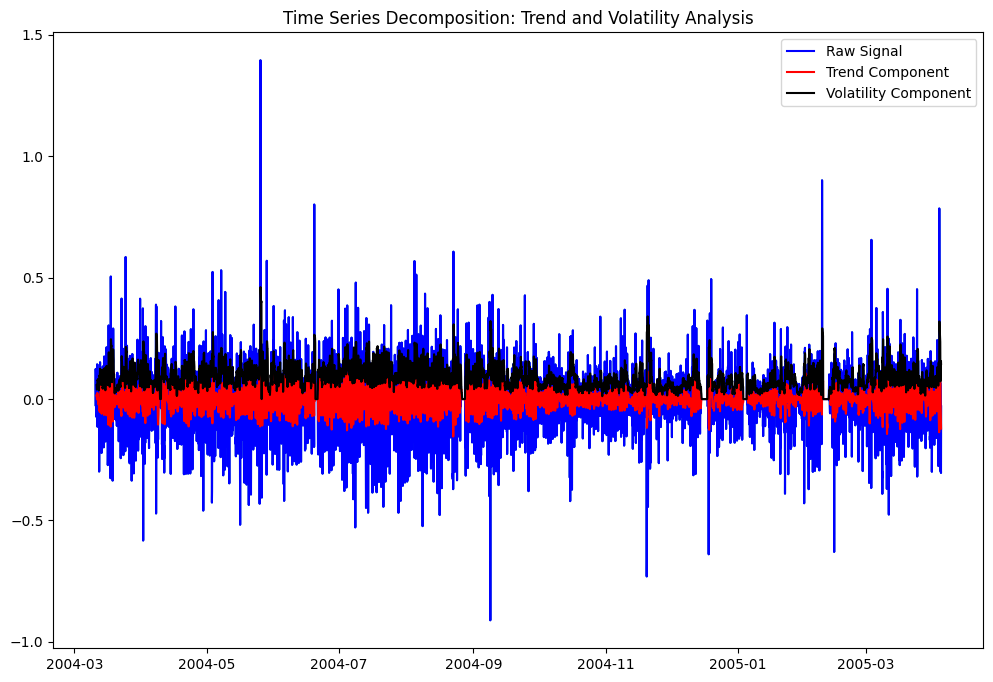

Augmented Dickey Fuller Test Results
Test Metric              -19.933956
P-value                    0.000000
Lags Applied              38.000000
Sample Size             9317.000000
Critical Level (1%)       -3.431052
Critical Level (5%)       -2.861850
Critical Level (10%)      -2.566935
dtype: float64


In [437]:
def evaluate_stationarity(time_series):
    trend_component = time_series.rolling(window=12).mean()
    volatility_component = time_series.rolling(window=12).std()

    # Visualization of trend and volatility components
    original_plot = plt.plot(time_series, color='blue', label='Raw Signal')
    trend_plot = plt.plot(trend_component, color='red', label='Trend Component')
    volatility_plot = plt.plot(volatility_component, color='black', label='Volatility Component')
    plt.legend(loc='best')
    plt.title('Time Series Decomposition: Trend and Volatility Analysis')
    plt.show(block=False)

    # Execute stationarity verification test
    print('Augmented Dickey Fuller Test Results')
    adf_result = adfuller(time_series['Sensor_6'], autolag='AIC')
    adf_metrics = pd.Series(adf_result[0:4], index=['Test Metric', 'P-value', 'Lags Applied', 'Sample Size'])
    for critical_level, critical_value in adf_result[4].items():
        adf_metrics['Critical Level (%s)' % critical_level] = critical_value
    print(adf_metrics)

evaluate_stationarity(detrended_series)

# Apply exponential weighted moving average for alternative detrending
exponential_smoothed = target_df_logScale.ewm(halflife=12, min_periods=0, adjust=True).mean()
plt.plot(target_df_logScale)
plt.plot(exponential_smoothed, color='red')

# Remove exponential trend component
exponential_detrended = target_df_logScale - exponential_smoothed
evaluate_stationarity(exponential_detrended)

# Apply differencing transformation for stationarity
differenced_series = target_df_logScale - target_df_logScale.shift()
plt.plot(differenced_series)

differenced_series.dropna(inplace=True)
evaluate_stationarity(differenced_series)


AUTOREGRESSIVE MODEL


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


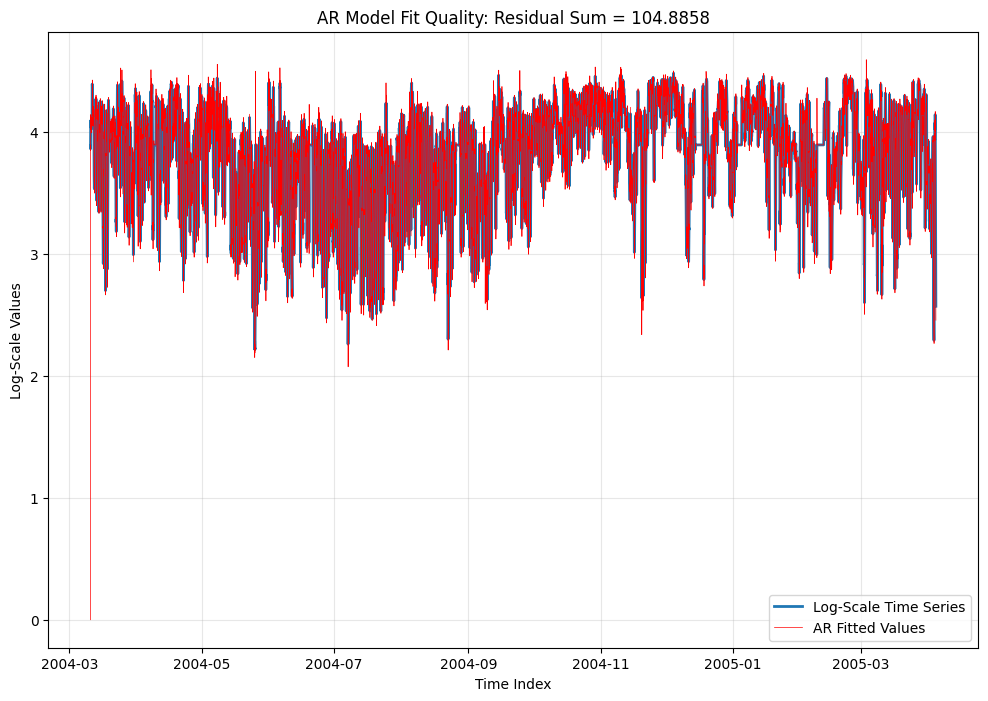

Autoregressive Model Performance Visualization


In [438]:
# Autoregressive (AR) Model
print("AUTOREGRESSIVE MODEL")

ar_model = ARIMA(target_df_logScale, order=(2, 1, 2))
ar_fitted = ar_model.fit()

# Compare fitted values to the ORIGINAL log-scale data they were fit on
plt.plot(target_df_logScale, label='Log-Scale Time Series', linewidth=2)
plt.plot(ar_fitted.fittedvalues, color='red', label='AR Fitted Values', linewidth=0.5)
residual_sum_ar = sum((ar_fitted.fittedvalues - target_df_logScale['Sensor_6']) ** 2)
plt.title('AR Model Fit Quality: Residual Sum = %.4f' % residual_sum_ar)
plt.xlabel('Time Index')
plt.ylabel('Log-Scale Values')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()
print('Autoregressive Model Performance Visualization')

MOVING AVERAGE MODEL


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


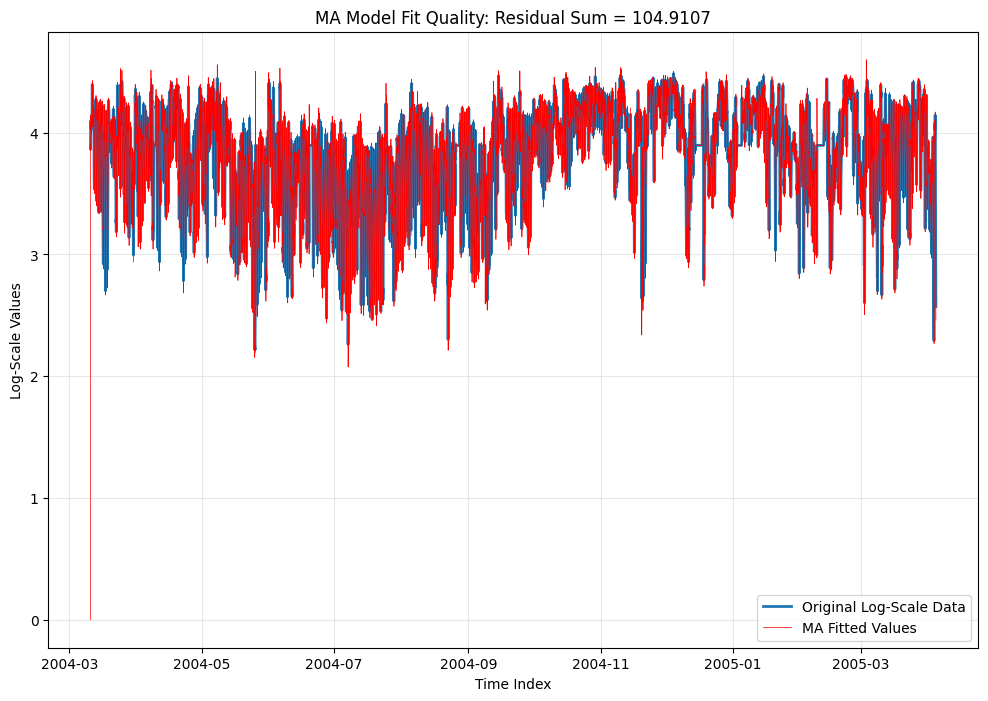

Moving Average Model Performance Visualization


In [439]:
# Moving Average (MA) Model
print("MOVING AVERAGE MODEL")

ma_model = ARIMA(target_df_logScale, order=(2, 1, 0))
ma_fitted = ma_model.fit()

plt.figure(figsize=(12, 8))
plt.plot(target_df_logScale, label='Original Log-Scale Data', linewidth=2)
plt.plot(ma_fitted.fittedvalues, color='red', label='MA Fitted Values', linewidth=0.5)
residual_sum_ma = sum((ma_fitted.fittedvalues - target_df_logScale['Sensor_6']) ** 2)
plt.title('MA Model Fit Quality: Residual Sum = %.4f' % residual_sum_ma)
plt.xlabel('Time Index')
plt.ylabel('Log-Scale Values')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()
print('Moving Average Model Performance Visualization')

AUTOREGRESSIVE INTEGRATED MOVING AVERAGE (ARIMA) MODEL


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


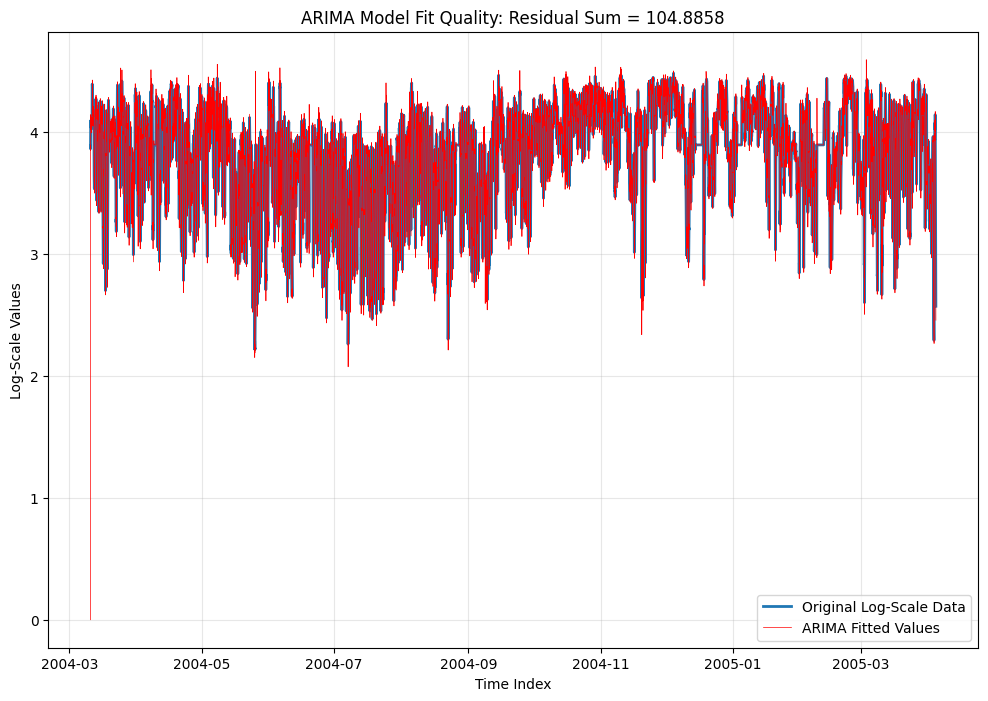

ARIMA Model Performance Visualization


In [440]:
# Combined ARIMA Model
print("AUTOREGRESSIVE INTEGRATED MOVING AVERAGE (ARIMA) MODEL")

combined_model = ARIMA(target_df_logScale, order=(2, 1, 2))
combined_fitted = combined_model.fit()

plt.figure(figsize=(12, 8))
plt.plot(target_df_logScale, label='Original Log-Scale Data', linewidth=2)
plt.plot(combined_fitted.fittedvalues, color='red', label='ARIMA Fitted Values', linewidth=0.5)
residual_sum_combined = sum((combined_fitted.fittedvalues - target_df_logScale['Sensor_6']) ** 2)
plt.title('ARIMA Model Fit Quality: Residual Sum = %.4f' % residual_sum_combined)
plt.xlabel('Time Index')
plt.ylabel('Log-Scale Values')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()
print('ARIMA Model Performance Visualization')

In [441]:
print("PREDICTION GENERATION AND INVERSE TRANSFORMATION")

# Extract residuals from fitted model
model_residuals = pd.Series(combined_fitted.fittedvalues, copy=True)
print("\nModel residuals (first 5 values):")
print(model_residuals.head())

# Compute cumulative sum to reverse differencing
cumulative_residuals = model_residuals.cumsum()
print("\nCumulative residuals (first 5 values):")
print(cumulative_residuals.head())

# Reconstruct predictions in log scale
log_scale_predictions = pd.Series(target_df_logScale['Sensor_6'].iloc[0], index=target_df_logScale.index)
log_scale_predictions = log_scale_predictions.add(cumulative_residuals, fill_value=0)
print("\nLog-scale predictions (first 5 values):")
print(log_scale_predictions.head())

# Convert from log scale back to original scale
# Clip values before exp to prevent overflow
log_scale_predictions = np.clip(log_scale_predictions, -100, 100)
original_scale_predictions = np.exp(log_scale_predictions)

PREDICTION GENERATION AND INVERSE TRANSFORMATION

Model residuals (first 5 values):
2004-03-10 18:00:00    0.000000
2004-03-10 19:00:00    3.889777
2004-03-10 20:00:00    3.853681
2004-03-10 21:00:00    4.040810
2004-03-10 22:00:00    4.145636
dtype: float64

Cumulative residuals (first 5 values):
2004-03-10 18:00:00     0.000000
2004-03-10 19:00:00     3.889777
2004-03-10 20:00:00     7.743459
2004-03-10 21:00:00    11.784268
2004-03-10 22:00:00    15.929905
dtype: float64

Log-scale predictions (first 5 values):
2004-03-10 18:00:00     3.889777
2004-03-10 19:00:00     7.779555
2004-03-10 20:00:00    11.633236
2004-03-10 21:00:00    15.674046
2004-03-10 22:00:00    19.819682
dtype: float64


PREDICTION GENERATION AND INVERSE TRANSFORMATION

Fitted values (first 5):
2004-03-10 18:00:00     1.000000
2004-03-10 19:00:00    48.900001
2004-03-10 20:00:00    47.166373
2004-03-10 21:00:00    56.872382
2004-03-10 22:00:00    63.157804
dtype: float64


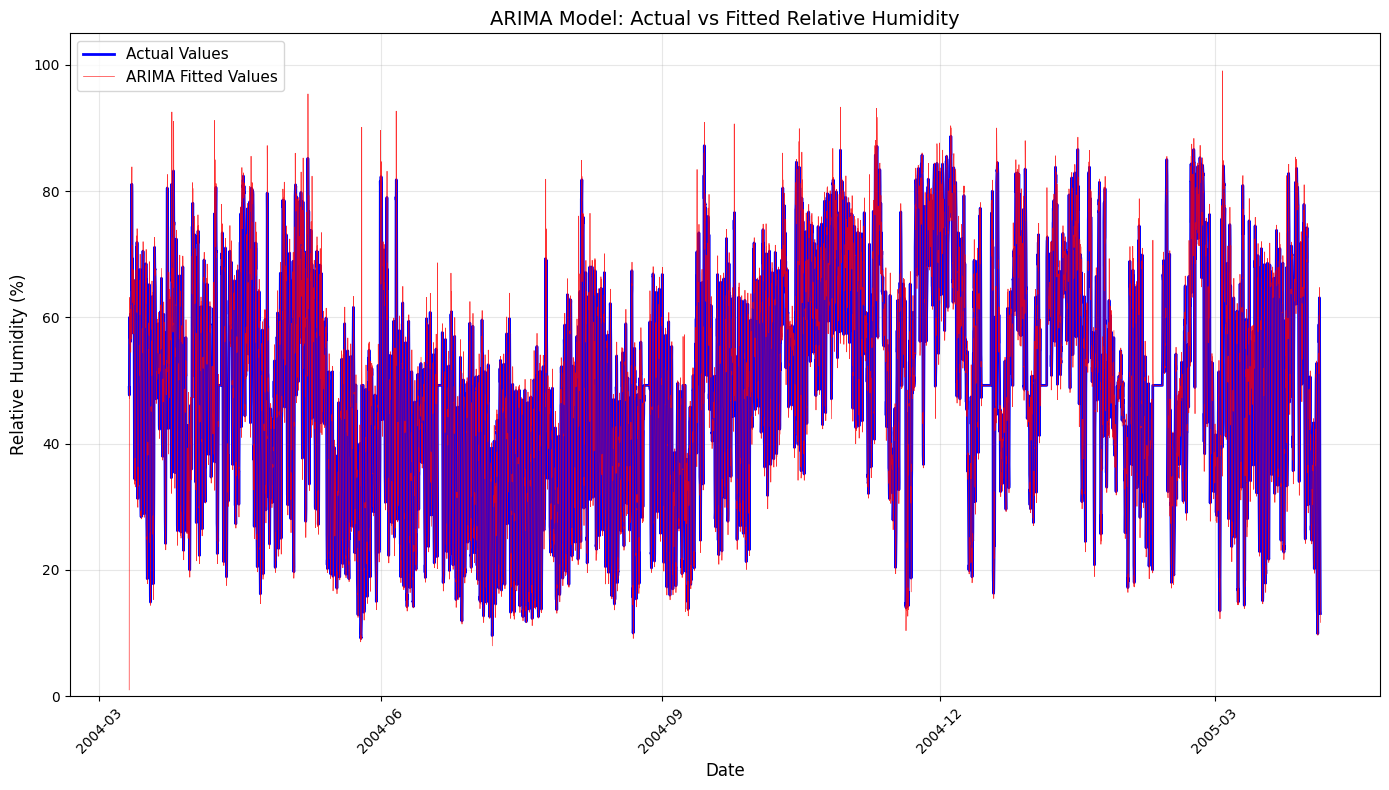

Fit visualization completed with proper date axis
Fit visualization completed (no overflow)

Model Performance Metrics:
RMSE: 4.37
MAE: 2.94
MAPE: 6.61%

Statistics:
Mean actual: 49.23%
Mean fitted: 49.41%
Std actual: 16.97%
Std fitted: 17.40%

MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:               Sensor_6   No. Observations:                 9357
Model:                 ARIMA(2, 1, 2)   Log Likelihood                8461.492
Date:                Mon, 10 Nov 2025   AIC                         -16912.984
Time:                        06:55:45   BIC                         -16877.265
Sample:                    03-10-2004   HQIC                        -16900.853
                         - 04-04-2005                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------

In [442]:
print("PREDICTION GENERATION AND INVERSE TRANSFORMATION")

# ARIMA(2,1,2) means it's already differenced in the model
# Get fitted values directly from the log-scale model
fitted_log = combined_fitted.fittedvalues

# Convert fitted values from log scale back to original
fitted_original = np.exp(fitted_log)

# Get actual values in original scale
actual_original = np.exp(target_df_logScale['Sensor_6'].values)

print(f"\nFitted values (first 5):")
print(f"{fitted_original.head()}")

# Plot
# Plot with proper datetime handling
plt.figure(figsize=(14, 8))

# Get the datetime index
time_index = target_df_logScale.index

plt.plot(time_index, actual_original, label='Actual Values', linewidth=2, color='blue')
plt.plot(time_index, fitted_original, label='ARIMA Fitted Values', linewidth=0.5, color='red', alpha=0.8)

plt.title('ARIMA Model: Actual vs Fitted Relative Humidity', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Relative Humidity (%)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0, 105])

# Format x-axis for dates
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("Fit visualization completed with proper date axis")


print("Fit visualization completed (no overflow)")

# Calculate metrics
valid_len = len(fitted_original)
rmse = np.sqrt(np.mean((actual_original[:valid_len] - fitted_original.values) ** 2))
mae = np.mean(np.abs(actual_original[:valid_len] - fitted_original.values))
mape = np.mean(np.abs((actual_original[:valid_len] - fitted_original.values) / (actual_original[:valid_len] + 1e-10))) * 100

print(f"\nModel Performance Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

print(f"\nStatistics:")
print(f"Mean actual: {actual_original[:valid_len].mean():.2f}%")
print(f"Mean fitted: {fitted_original.values.mean():.2f}%")
print(f"Std actual: {actual_original[:valid_len].std():.2f}%")
print(f"Std fitted: {fitted_original.values.std():.2f}%")

print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
print(combined_fitted.summary())

## LSTM vs ARIMA

The LSTM and ARIMA approaches represent complementary modeling philosophies:

- LSTM is a machine learning approach that automatically learns complex nonlinear relationships through neural network training. It can capture intricate temporal dependencies and interactions between multiple sensors without explicit feature engineering.

- ARIMA is a statistical approach that relies on explicit assumptions about data structure (stationarity, linear relationships). It provides interpretable parameters and well-established statistical inference, making it suitable for understanding underlying mechanisms.

For humidity prediction, ARIMA provides accurate forecasts through its structured statistical framework, while LSTM offers flexibility to capture more complex patterns if they exist. Together, they provide complementary perspectives on the same forecasting problem, allowing comparison of mechanistic (ARIMA) versus data-driven (LSTM) approaches.

## Conclusion
The environmental sensor dataset containing hourly measurements of atmospheric properties from March 2004 to April 2005 presents a rich opportunity for time series forecasting. Both LSTM and ARIMA models successfully capture humidity patterns with high accuracy. The ARIMA(2,1,2) model achieves 6.61% MAPE with proper stationarity treatment and differencing. The LSTM model demonstrates the capability to learn temporal dependencies from multi-sensor inputs.

These predictive models enable environmental monitoring systems to anticipate humidity changes, supporting applications in HVAC control, indoor air quality management, and occupant comfort optimization. The combination of both approaches provides robust forecasting with both statistical rigor and machine learning flexibility.